In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.extmath import randomized_svd
from scipy.signal import savgol_filter, find_peaks
from transformers import AutoTokenizer
import torch

In [2]:
import sys
sys.path.append("./cluster_anlys")

from spectrum_pipeline import run_spectrum_pipeline, print_spectrum_summary, plot_spectrum_diagnostics

# Mistral-7B

In [3]:
model_name = "mistralai/Mistral-7B-v0.1"
# ===== Step 1: Load tokenizer =====
tokenizer_path = f"{model_name}/tokenizer" 
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
print(f"[✓] Tokenizer loaded from: {tokenizer_path}")

# ===== Step 2: Load lm_head.weight =====
space_name = "output_proj"
lm_head_path = f"{model_name}/tensors/{space_name}.pt" 
embedding_matrix = torch.load(lm_head_path, map_location="cpu")
print(f"[✓] lm_head.weight loaded: shape = {embedding_matrix.shape}")
embedding_matrix = embedding_matrix.to(torch.float32)
# embedding_matrix = embedding_matrix.cpu().to(torch.float32).numpy()
print(f"[✓] lm_head.weight loaded: shape = {embedding_matrix.shape}")

[✓] Tokenizer loaded from: mistralai/Mistral-7B-v0.1/tokenizer
[✓] lm_head.weight loaded: shape = torch.Size([32000, 4096])
[✓] lm_head.weight loaded: shape = torch.Size([32000, 4096])


In [4]:
result = run_spectrum_pipeline(
    embedding_matrix,
    svd_mode="full",              # full spectrum
    device=embedding_matrix.device.type if embedding_matrix.is_cuda else None,
    use_squared=True,             # y(d) = log(sigma_d^2)
    smoothing=None,               # 不平滑
    top_k_inflections=4,
    min_gap=128,
    take_abs_curvature=False,
    use_abs_for_peak_ranking=True,
    energy_thresholds=(0.5, 0.75, 0.9, 0.95),
    combine_mode="union",         # inflection_dims ∪ energy_dims
)

In [5]:
print_spectrum_summary(result, top_n=10)

=== Spectrum Summary ===

Top singular values:
   1  σ=16.138685  energy_ratio=0.110923
   2  σ=2.314828  energy_ratio=0.002282
   3  σ=2.193521  energy_ratio=0.002049
   4  σ=2.149795  energy_ratio=0.001968
   5  σ=1.885114  energy_ratio=0.001513
   6  σ=1.830650  energy_ratio=0.001427
   7  σ=1.684758  energy_ratio=0.001209
   8  σ=1.629061  energy_ratio=0.001130
   9  σ=1.580443  energy_ratio=0.001064
  10  σ=1.532073  energy_ratio=0.001000

Energy thresholds:
dim= 997  cumulative_energy=0.5001
dim=2084  cumulative_energy=0.7501
dim=3031  cumulative_energy=0.9000
dim=3459  cumulative_energy=0.9500

Inflection dims:
[5, 142, 3938, 4088]

Candidate dims (final D):
[5, 142, 997, 2084, 3031, 3459, 3938, 4088]


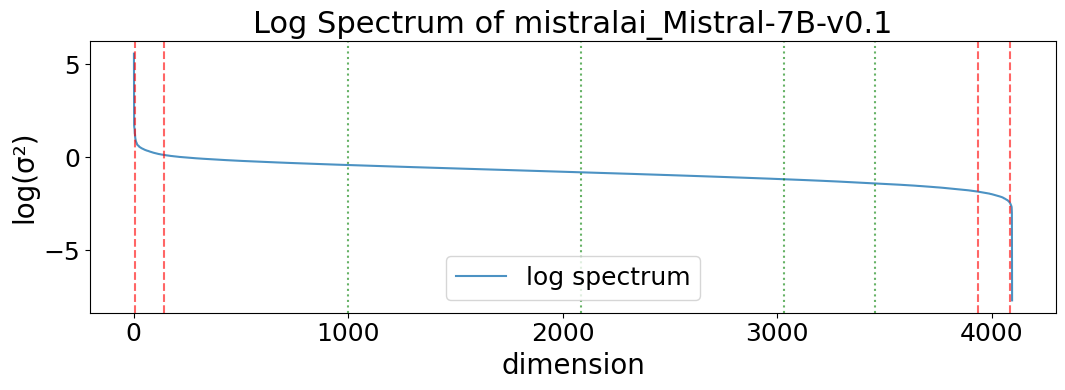

PosixPath('res/spectrum/mistralai_Mistral-7B-v0.1_spectrum_diagnostics.pdf')

In [6]:
plot_spectrum_diagnostics(result, xscale="linear", model_name=model_name)
# plot_spectrum_diagnostics(result, xscale="log")

# Mixtral-8x7B

In [7]:
model_name = "mistralai/Mixtral-8x7B-v0.1"
# ===== Step 1: Load tokenizer =====
tokenizer_path = f"{model_name}/tokenizer" 
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
print(f"[✓] Tokenizer loaded from: {tokenizer_path}")

# ===== Step 2: Load lm_head.weight =====
space_name = "output_proj"
lm_head_path = f"{model_name}/tensors/{space_name}.pt" 
embedding_matrix = torch.load(lm_head_path, map_location="cpu")
print(f"[✓] lm_head.weight loaded: shape = {embedding_matrix.shape}")
embedding_matrix = embedding_matrix.to(torch.float32)
# embedding_matrix = embedding_matrix.cpu().to(torch.float32).numpy()
print(f"[✓] lm_head.weight loaded: shape = {embedding_matrix.shape}")

[✓] Tokenizer loaded from: mistralai/Mixtral-8x7B-v0.1/tokenizer
[✓] lm_head.weight loaded: shape = torch.Size([32000, 4096])
[✓] lm_head.weight loaded: shape = torch.Size([32000, 4096])


In [8]:
result = run_spectrum_pipeline(
    embedding_matrix,
    svd_mode="full",              # full spectrum
    device=embedding_matrix.device.type if embedding_matrix.is_cuda else None,
    use_squared=True,             # y(d) = log(sigma_d^2)
    smoothing=None,               # 不平滑
    top_k_inflections=4,
    min_gap=128,
    take_abs_curvature=False,
    use_abs_for_peak_ranking=True,
    energy_thresholds=(0.5, 0.75, 0.9, 0.95),
    combine_mode="union",         # inflection_dims ∪ energy_dims
)

In [9]:
print_spectrum_summary(result, top_n=10)

=== Spectrum Summary ===

Top singular values:
   1  σ=26.279310  energy_ratio=0.059172
   2  σ=7.141376  energy_ratio=0.004370
   3  σ=5.361146  energy_ratio=0.002463
   4  σ=4.929482  energy_ratio=0.002082
   5  σ=4.589211  energy_ratio=0.001805
   6  σ=4.346421  energy_ratio=0.001619
   7  σ=4.227377  energy_ratio=0.001531
   8  σ=3.781553  energy_ratio=0.001225
   9  σ=3.694566  energy_ratio=0.001170
  10  σ=3.587061  energy_ratio=0.001102

Energy thresholds:
dim=1111  cumulative_energy=0.5002
dim=2156  cumulative_energy=0.7502
dim=3052  cumulative_energy=0.9000
dim=3457  cumulative_energy=0.9500

Inflection dims:
[8, 158, 3957, 4093]

Candidate dims (final D):
[8, 158, 1111, 2156, 3052, 3457, 3957, 4093]


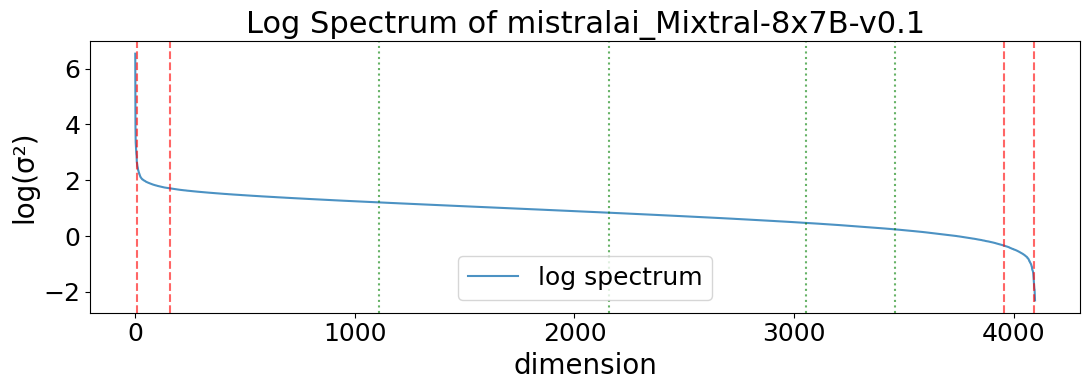

PosixPath('res/spectrum/mistralai_Mixtral-8x7B-v0.1_spectrum_diagnostics.pdf')

In [10]:
plot_spectrum_diagnostics(result, xscale="linear", model_name=model_name)
# plot_spectrum_diagnostics(result, xscale="log")

# gpt-oss-20B

In [11]:
model_name = "gpt-oss"
space_name = "output_proj"
# ===== Step 1: Load tokenizer =====
tokenizer_path = f"{model_name}/tokenizer" 
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
print(f"[✓] Tokenizer loaded from: {tokenizer_path}")

# ===== Step 2: Load lm_head.weight =====
space_name = "output_proj"
lm_head_path = f"{model_name}/tensors/{space_name}.pt" 
embedding_matrix = torch.load(lm_head_path, map_location="cpu")
print(f"[✓] lm_head.weight loaded: shape = {embedding_matrix.shape}")
embedding_matrix = embedding_matrix.to(torch.float32)
# embedding_matrix = embedding_matrix.cpu().to(torch.float32).numpy()
print(f"[✓] lm_head.weight loaded: shape = {embedding_matrix.shape}")

[✓] Tokenizer loaded from: gpt-oss/tokenizer
[✓] lm_head.weight loaded: shape = torch.Size([201088, 2880])
[✓] lm_head.weight loaded: shape = torch.Size([201088, 2880])


In [12]:
result = run_spectrum_pipeline(
    embedding_matrix,
    svd_mode="full",              # full spectrum
    device=embedding_matrix.device.type if embedding_matrix.is_cuda else None,
    use_squared=True,             # y(d) = log(sigma_d^2)
    smoothing=None,               # 不平滑
    top_k_inflections=4,
    min_gap=128,
    take_abs_curvature=False,
    use_abs_for_peak_ranking=True,
    energy_thresholds=(0.5, 0.75, 0.9, 0.95),
    combine_mode="union",         # inflection_dims ∪ energy_dims
)

In [13]:
print_spectrum_summary(result, top_n=10)

=== Spectrum Summary ===

Top singular values:
   1  σ=22.566792  energy_ratio=0.031373
   2  σ=11.849593  energy_ratio=0.008650
   3  σ=9.884230  energy_ratio=0.006019
   4  σ=9.208690  energy_ratio=0.005224
   5  σ=8.352577  energy_ratio=0.004298
   6  σ=7.321667  energy_ratio=0.003302
   7  σ=7.226995  energy_ratio=0.003218
   8  σ=7.009602  energy_ratio=0.003027
   9  σ=6.786899  energy_ratio=0.002838
  10  σ=6.564515  energy_ratio=0.002655

Energy thresholds:
dim= 739  cumulative_energy=0.5002
dim=1591  cumulative_energy=0.7501
dim=2264  cumulative_energy=0.9002
dim=2532  cumulative_energy=0.9502

Inflection dims:
[6, 182, 466, 2868]

Candidate dims (final D):
[6, 182, 466, 739, 1591, 2264, 2532, 2868]


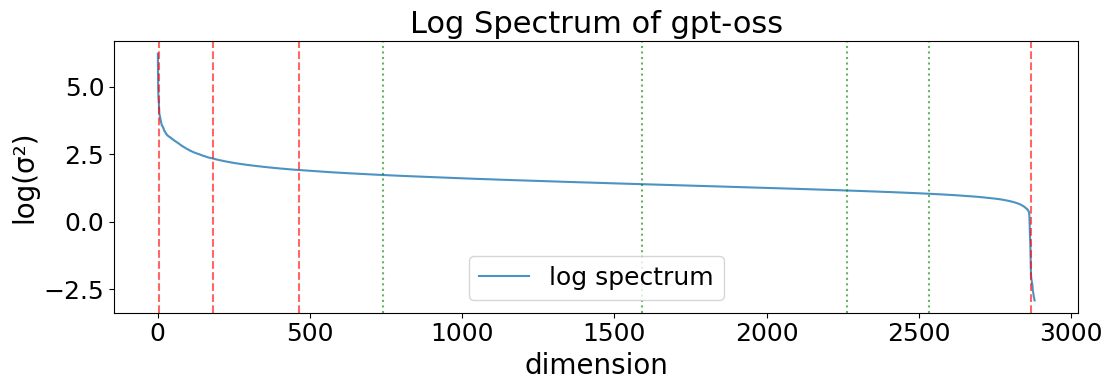

PosixPath('res/spectrum/gpt-oss_spectrum_diagnostics.pdf')

In [14]:
plot_spectrum_diagnostics(result, xscale="linear", model_name=model_name)

In [ ]:
candidate_dims = [int(x) for x in result.candidate_dims]

hdbscan_param_grid = make_hdbscan_param_grid(
    min_cluster_size_list=[5, 10],
    min_samples_list=[1, 5],
    metric_list=["euclidean"],
    cluster_selection_method_list=["eom"],
    cluster_selection_epsilon_list=[0.0],
)


In [15]:

summary_df = run_pca_hdbscan_grid(
    embedding_matrix=embedding_matrix,          # torch.Tensor [32000, 4096]
    candidate_dims=candidate_dims,
    pca_seed_list=[0, 1, 2],
    hdbscan_param_grid=hdbscan_param_grid,
    model_name="mistralai/Mistral-7B-v0.1",
    space_name="output_proj",
    out_root="comp",
    l2_norm=False,
    svd_solver="randomized",
)

[i] Input matrix shape: (32000, 4096)
[i] Candidate dims: [8, 47, 108, 158, 1111, 1914, 2421, 3052, 3457, 3855, 3917, 3980, 4019, 4057, 4093]
[i] Number of PCA seeds: 3
[i] Number of HDBSCAN configs: 4
[✓] PCA finished | dim=8 seed=0 time=0.85s cum_var=0.030024

[i] Run 00001 | dim=8 seed=0 params={'min_cluster_size': 5, 'min_samples': 1, 'metric': 'euclidean', 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0}
[i] HDBSCAN params | min_cluster_size=5, min_samples=1, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-03-16 11:19:09.372] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (0.48s)
[✓] CSV  → comp/mistralai/Mistral-7B-v0.1/output_proj/clusters/run_00001_clusters.csv
[✓] META → comp/mistralai/Mistral-7B-v0.1/output_proj/meta/run_00001_meta.json

[i] Run 00002 | dim=8 seed=0 params={'min_cluster_size': 5, 'min_samples': 5, 'metric': 'euclidean', 'cluster_selection_method': 'eom'

In [11]:
import pandas as pd


def print_cluster_result_from_csv(
    csv_path,
    tokenizer,
    top_k=20,
    include_noise_tokens=False,
    sort_clusters_by="cluster_id",   # "cluster_id" | "size" | "mean_prob"
):
    """
    Read one token-level cluster CSV from the PCA -> L2 -> GPU HDBSCAN pipeline
    and print cluster summaries.

    Expected CSV columns:
        - token_id
        - cluster_id
        - probability

    Args:
        csv_path: path to clusters/run_XXXXX_clusters.csv
        tokenizer: HF tokenizer
        top_k: print top-k highest-probability tokens per cluster
        include_noise_tokens: whether to print all noise tokens
        sort_clusters_by:
            - "cluster_id": ascending cluster id
            - "size": descending cluster size
            - "mean_prob": descending cluster mean probability
    """
    df = pd.read_csv(csv_path)

    required_cols = {"token_id", "cluster_id", "probability"}
    if not required_cols.issubset(df.columns):
        raise ValueError(
            f"CSV must contain columns {required_cols}, got {set(df.columns)}"
        )

    total_tokens = len(df)

    # ===== noise statistics =====
    noise_df = df[df["cluster_id"] == -1].copy()
    noise_tokens = len(noise_df)
    noise_ratio = (noise_tokens / total_tokens * 100.0) if total_tokens > 0 else 0.0

    # ===== non-noise statistics =====
    df_no_noise = df[df["cluster_id"] != -1].copy()

    if len(df_no_noise) == 0:
        print(f"[File] {csv_path}")
        print("No non-noise clusters found.")
        print(
            f"Noise tokens: {noise_tokens} / {total_tokens} "
            f"({noise_ratio:.2f}%)"
        )
        if include_noise_tokens and noise_tokens > 0:
            print("\nNoise tokens (cluster_id = -1):")
            noise_token_strs = []
            for tid in noise_df["token_id"].astype(int).tolist():
                try:
                    tok_str = tokenizer.decode([tid])
                except Exception:
                    tok_str = tokenizer.convert_ids_to_tokens([tid])[0]
                noise_token_strs.append(tok_str)
            print(", ".join(noise_token_strs))
        return

    global_mean = df_no_noise["probability"].mean()
    global_std = df_no_noise["probability"].std(ddof=0)

    # ===== cluster-level summary table =====
    cluster_summary = (
        df_no_noise.groupby("cluster_id", as_index=False)
        .agg(
            size=("token_id", "count"),
            mean_prob=("probability", "mean"),
            std_prob=("probability", "std"),
            max_prob=("probability", "max"),
            min_prob=("probability", "min"),
        )
    )

    cluster_summary["std_prob"] = cluster_summary["std_prob"].fillna(0.0)

    if sort_clusters_by == "cluster_id":
        cluster_summary = cluster_summary.sort_values("cluster_id", ascending=True)
    elif sort_clusters_by == "size":
        cluster_summary = cluster_summary.sort_values(
            ["size", "cluster_id"], ascending=[False, True]
        )
    elif sort_clusters_by == "mean_prob":
        cluster_summary = cluster_summary.sort_values(
            ["mean_prob", "cluster_id"], ascending=[False, True]
        )
    else:
        raise ValueError(
            "sort_clusters_by must be one of: 'cluster_id', 'size', 'mean_prob'"
        )

    n_clusters = len(cluster_summary)

    print(f"[File] {csv_path}")
    print(
        f"Clusters (excluding noise): {n_clusters}\n"
        f"Total tokens: {total_tokens}\n"
        f"Noise tokens: {noise_tokens} / {total_tokens} ({noise_ratio:.2f}%)\n"
        f"Global probability mean = {global_mean:.4f}, "
        f"std = {global_std:.4f} (excluding noise)"
    )
    print("-" * 80)

    # ===== print each cluster =====
    for _, row in cluster_summary.iterrows():
        cid = int(row["cluster_id"])
        size = int(row["size"])
        mean_prob = float(row["mean_prob"])
        std_prob = float(row["std_prob"])
        max_prob = float(row["max_prob"])
        min_prob = float(row["min_prob"])

        sub = df_no_noise[df_no_noise["cluster_id"] == cid].copy()
        top = sub.sort_values("probability", ascending=False).head(top_k)

        tokens = []
        for tid in top["token_id"].astype(int).tolist():
            try:
                tok_str = tokenizer.decode([tid])
            except Exception:
                tok_str = tokenizer.convert_ids_to_tokens([tid])[0]
            tokens.append(tok_str)

        print(
            f"Cluster {cid} | "
            f"size={size} | "
            f"mean_prob={mean_prob:.4f} | "
            f"std_prob={std_prob:.4f} | "
            f"max_prob={max_prob:.4f} | "
            f"min_prob={min_prob:.4f}"
        )
        print(", ".join(tokens))
        print()

    # ===== optionally print noise tokens =====
    if include_noise_tokens:
        if noise_tokens > 0:
            print("-" * 80)
            print("Noise tokens (cluster_id = -1):")
            noise_token_strs = []
            for tid in noise_df["token_id"].astype(int).tolist():
                try:
                    tok_str = tokenizer.decode([tid])
                except Exception:
                    tok_str = tokenizer.convert_ids_to_tokens([tid])[0]
                noise_token_strs.append(tok_str)
            print(", ".join(noise_token_strs))
        else:
            print("-" * 80)
            print("No noise tokens.")

In [14]:
csv_path = "comp/mistralai/Mistral-7B-v0.1/output_proj/clusters_l2=True/run_00001_clusters.csv"

print_cluster_result_from_csv(
    csv_path=csv_path,
    tokenizer=tokenizer,
    top_k=20,
    include_noise_tokens=False,
    sort_clusters_by="size",
)

[File] comp/mistralai/Mistral-7B-v0.1/output_proj/clusters/run_00001_clusters.csv
Clusters (excluding noise): 1423
Total tokens: 32000
Noise tokens: 19022 / 32000 (59.44%)
Global probability mean = 0.9624, std = 0.0816 (excluding noise)
--------------------------------------------------------------------------------
Cluster 1378 | size=182 | mean_prob=0.9176 | std_prob=0.2758 | max_prob=1.0000 | min_prob=0.0000
, , , , , , , , , , ,, , , 

Cluster 1279 | size=112 | mean_prob=0.9897 | std_prob=0.0218 | max_prob=1.0000 | min_prob=0.9297
in, er, on, re, at, en, or, es, al, an, is, it, ed, ar, as, le, per, est, el, il

Cluster 612 | size=108 | mean_prob=0.9884 | std_prob=0.0254 | max_prob=1.0000 | min_prob=0.9147
pgfqpoint, ят, утбо, ationToken, ристо, тей, ល, ్, ێ, ್, ်, Населення, ి, ព, ು, ರ, ច, ី, 府, ដ

Cluster 668 | size=70 | mean_prob=0.9778 | std_prob=0.0445 | max_prob=1.0000 | min_prob=0.8468
EO, PU, VD, VT, TF, HL, RW, VB, RM, DL, HW, NL, RF, NV, VP, VR, VC, RG, FX, SB

In [16]:
csv_path = "comp/mistralai/Mistral-7B-v0.1/output_proj/clusters_l2=True/run_00027_clusters.csv"

print_cluster_result_from_csv(
    csv_path=csv_path,
    tokenizer=tokenizer,
    top_k=20,
    include_noise_tokens=False,
    sort_clusters_by="size",
)

[File] comp/mistralai/Mistral-7B-v0.1/output_proj/clusters_l2=True/run_00027_clusters.csv
Clusters (excluding noise): 365
Total tokens: 32000
Noise tokens: 24270 / 32000 (75.84%)
Global probability mean = 0.9628, std = 0.1037 (excluding noise)
--------------------------------------------------------------------------------
Cluster 361 | size=262 | mean_prob=0.9310 | std_prob=0.0784 | max_prob=1.0000 | min_prob=0.7803
!, </s>, 	, 
,  ,   ,              , such, For, these, W, he, with, an, R, r, F, it, H, You

Cluster 337 | size=212 | mean_prob=0.7217 | std_prob=0.4492 | max_prob=1.0000 | min_prob=0.0000
, , , , , , , , , , ,, , , 

Cluster 240 | size=175 | mean_prob=0.9878 | std_prob=0.0181 | max_prob=1.0000 | min_prob=0.9455
ał, ła, ści, ří, ło, ně, ých, tó, ół, ają, ńsk, ły, ść, że, ostał, ší, nego, št, ię, owej

Cluster 122 | size=172 | mean_prob=0.9779 | std_prob=0.0336 | max_prob=1.0000 | min_prob=0.8914
ated, ied, ined, ased, ited, ired, ared, ized, ished, ved, ided, 

In [ ]:
def plot_spectrum_diagnostics(result):

    s = result["singular_values"]

    log_spec = result["log_spectrum"]

    curvature = result["curvature"]

    inflection = result["inflection_dims"]

    energy_dims = result["energy_dims"]


    fig, axes = plt.subplots(2, 1, figsize=(10, 8))


    # -------- spectrum --------

    axes[0].plot(log_spec, label="log spectrum")

    for d in inflection:
        axes[0].axvline(d, color="red", linestyle="--", alpha=0.6)

    for d in energy_dims:
        axes[0].axvline(d, color="green", linestyle=":", alpha=0.6)

    axes[0].set_title("Log Spectrum")

    axes[0].set_xlabel("dimension")

    axes[0].set_ylabel("log(σ²)")

    axes[0].legend()


    # -------- curvature --------

    axes[1].plot(curvature, label="curvature Δ²y")

    for d in inflection:
        axes[1].axvline(d, color="red", linestyle="--", alpha=0.6)

    axes[1].set_title("Spectrum Curvature")

    axes[1].set_xlabel("dimension")

    axes[1].set_ylabel("Δ² log(σ²)")

    axes[1].legend()


    plt.tight_layout()

    plt.show()

In [ ]:
plot_spectrum_diagnostics(result)